In [98]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,classification_report,
    confusion_matrix
)

In [99]:
header_names = ['age','workclass','fnlwgt','education','education_num','marital_status','occupation','relationship','race','sex','capital_gain','capital_loss','hours_per_week','native_country','income']

In [100]:
data = pd.read_csv("data/adult.data",header=None,names=header_names)
test = pd.read_csv("data/adult.test")

In [101]:
df = pd.concat([data,test])

In [102]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,|1x3 Cross validator
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K,NaN
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K,NaN
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K,NaN
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K,NaN
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K,NaN


In [103]:
df.shape

(48842, 16)

In [104]:
len(df.columns)

16

In [105]:
df.drop('|1x3 Cross validator',axis=1,inplace=True)

In [106]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


In [107]:
df.isnull().sum()

age               16281
workclass         16281
fnlwgt            16281
education         16281
education_num     16281
marital_status    16281
occupation        16281
relationship      16281
race              16281
sex               16281
capital_gain      16281
capital_loss      16281
hours_per_week    16281
native_country    16281
income            16281
dtype: int64

In [108]:
df['workclass'].value_counts().sum()

np.int64(32561)

In [109]:
df.dropna(axis=0,inplace=True)

In [110]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

Is someone is earning <=50K : 0 , else >50K: 1

In [111]:
salary_map={
    " <=50K":0,
    " >50K":1
}

df['income'] = df['income'].map(salary_map)

In [112]:
print(df['income'].value_counts())
print(f"Overall rate earning greater than 50K: {round(df['income'].mean()*100,3)}%")

income
0    24720
1     7841
Name: count, dtype: int64
Overall rate earning greater than 50K: 24.081%


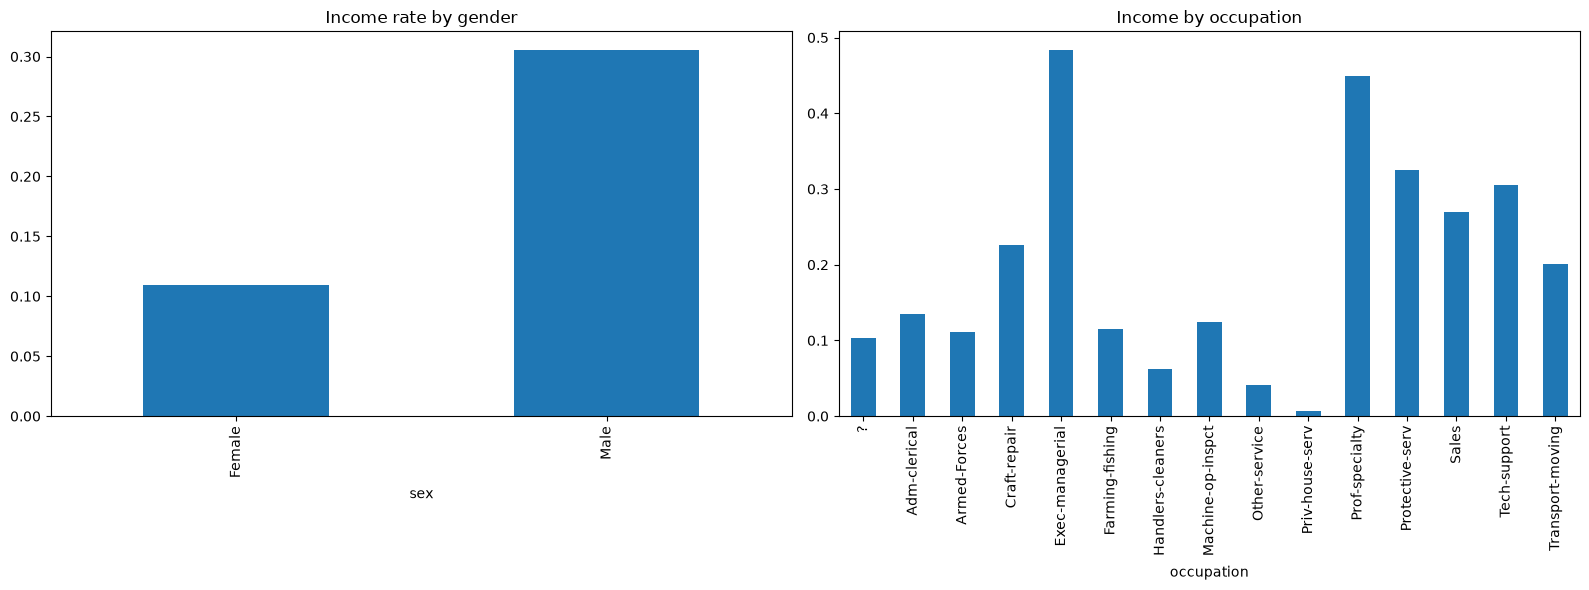

In [113]:
fig,axes = plt.subplots(1,2,figsize=(16,6))

df.groupby('sex')['income'].mean().plot(kind='bar',ax=axes[0],title="Income rate by gender")
df.groupby('occupation')['income'].mean().plot(kind='bar',ax=axes[1],title="Income by occupation")

plt.tight_layout()
plt.show()

In [114]:
drop_cols = ['education','marital_status','relationship','native_country']

X = df.drop(columns = ['income']+drop_cols)
y = df['income']

In [115]:
X

,age,workclass,fnlwgt,education_num,occupation,race,sex,capital_gain,capital_loss,hours_per_week
0,39.0,State-gov,77516.0,13.0,Adm-clerical,White,Male,2174.0,0.0,40.0
1,50.0,Self-emp-not-inc,83311.0,13.0,Exec-managerial,White,Male,0.0,0.0,13.0
2,38.0,Private,215646.0,9.0,Handlers-cleaners,White,Male,0.0,0.0,40.0
3,53.0,Private,234721.0,7.0,Handlers-cleaners,Black,Male,0.0,0.0,40.0
4,28.0,Private,338409.0,13.0,Prof-specialty,Black,Female,0.0,0.0,40.0
...,...,...,...,...,...,...,...,...,...,...
32556,27.0,Private,257302.0,12.0,Tech-support,White,Female,0.0,0.0,38.0
32557,40.0,Private,154374.0,9.0,Machine-op-inspct,White,Male,0.0,0.0,40.0
32558,58.0,Private,151910.0,9.0,Adm-clerical,White,Female,0.0,0.0,40.0
32559,22.0,Private,201490.0,9.0,Adm-clerical,White,Male,0.0,0.0,20.0


In [116]:
numeric_features = ['age','fnlwgt','education_num','capital_gain','capital_loss','hours_per_week']
categorical_features = ['workclass','occupation','race','sex']

Build the preprocessing pipeline

In [117]:
numeric_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy='median')),
    ("scaler",StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy='most_frequent')),
    ("encoding",OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ("num",numeric_transformer,numeric_features),
    ("categorical",categorical_transformer,categorical_features)
])

model = Pipeline(steps=[
    ("preprocessing",preprocessor),
    ("classfication",LogisticRegression(max_iter=1000,random_state=42))
])

In [118]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size = 0.2,
    stratify = y
)
print("Train: ",X_train.shape[0],"| Test: ",X_test.shape[0])

Train:  26048 | Test:  6513


Train the model

In [119]:
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('classfication', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['age','workclass','fnlwgt',...,'capital_gain','capital_loss', 'hours_per_week']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [120]:
y_pred = model.predict(X_test)

print("Accuracy score: ",round(accuracy_score(y_test,y_pred)*100,2),"%")
print("Classification Report : \n",classification_report(y_test,y_pred,target_names=['<=50K','>50K']))
print("Confusion matris: \n",confusion_matrix(y_test,y_pred))

Accuracy score:  83.31 %
Classification Report : 
               precision    recall  f1-score   support

       <=50K       0.85      0.94      0.90      4945
        >50K       0.73      0.49      0.59      1568

    accuracy                           0.83      6513
   macro avg       0.79      0.72      0.74      6513
weighted avg       0.82      0.83      0.82      6513

Confusion matris: 
 [[4654  291]
 [ 796  772]]


In [121]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

scores = cross_val_score(model,X,y,cv = cv,scoring='accuracy')
print("Scores for 5 fold: ",scores.round(3))
print("Mean CV score: ",scores.mean().round(3))

Scores for 5 fold:  [0.829 0.83  0.829 0.831 0.837]
Mean CV score:  0.831


Create the model package with joblib

In [122]:
joblib.dump(model,"model/adult_salary_pipeline.joblib")
print("Saved")

Saved


Load the model to prediction

In [123]:
loaded_model = joblib.load("model/adult_salary_pipeline.joblib")

In [124]:
loaded_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('classfication', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['age','workclass','fnlwgt',...,'capital_gain','capital_loss', 'hours_per_week']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [125]:
sample = pd.DataFrame([{
    "age":38, "workclass":"Private", "fnlwgt": 215646, "education_num":9, 
    "occupation":"Handlers-cleaners", "race":"White", "sex":"Male","capital_gain": 0, "capital_loss":0, "hours_per_week":40,
}])



In [126]:
pred = int(loaded_model.predict(sample)[0])
proba = float(loaded_model.predict_proba(sample)[0][pred])
label = ">50K" if pred == 1 else "<=50K"

print(f"Prediction: {pred} ({label}) | Probability: {round(proba,3)}")

Prediction: 0 (<=50K) | Probability: 0.893
